In [97]:
import pandas as pd
import numpy as np

In [98]:
import matplotlib.pyplot as plt
import seaborn as sns

In [99]:
data=pd.read_csv('Placement_Data_Full_Class.csv')

In [130]:
data.head()

,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,1,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed,270000.0
1,2,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed,200000.0
2,3,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed,250000.0
3,4,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,Not Placed,NaN
4,5,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed,425000.0


In [131]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 215 entries, 0 to 214
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   sl_no           215 non-null    int64  
 1   gender          215 non-null    object 
 2   ssc_p           215 non-null    float64
 3   ssc_b           215 non-null    object 
 4   hsc_p           215 non-null    float64
 5   hsc_b           215 non-null    object 
 6   hsc_s           215 non-null    object 
 7   degree_p        215 non-null    float64
 8   degree_t        215 non-null    object 
 9   workex          215 non-null    object 
 10  etest_p         215 non-null    float64
 11  specialisation  215 non-null    object 
 12  mba_p           215 non-null    float64
 13  status          215 non-null    object 
 14  salary          148 non-null    float64
dtypes: float64(6), int64(1), object(8)
memory usage: 25.3+ KB


In [132]:
data.shape

(215, 15)

In [133]:
data.isnull().sum()

sl_no              0
gender             0
ssc_p              0
ssc_b              0
hsc_p              0
hsc_b              0
hsc_s              0
degree_p           0
degree_t           0
workex             0
etest_p            0
specialisation     0
mba_p              0
status             0
salary            67
dtype: int64

In [134]:
data['salary'].unique()

array([270000., 200000., 250000.,     nan, 425000., 252000., 231000.,
       260000., 218000., 300000., 236000., 265000., 393000., 360000.,
       240000., 350000., 278000., 320000., 411000., 287000., 204000.,
       450000., 216000., 220000., 268000., 275000., 336000., 230000.,
       500000., 400000., 210000., 420000., 380000., 280000., 276000.,
       940000., 225000., 233000., 690000., 340000., 255000., 285000.,
       290000., 650000., 264000., 295000.])

In [135]:
print("Missing 'salary' count:", data['salary'].isnull().sum())
print("'Not Placed' count:", (data['status'] == 'Not Placed').sum())
print("These two numbers matching confirms salary is missing only for unplaced students.")


Missing 'salary' count: 67
'Not Placed' count: 67
These two numbers matching confirms salary is missing only for unplaced students.


In [136]:
data_clean=data.drop(columns=['salary','sl_no'])

In [137]:
data_clean.columns

Index(['gender', 'ssc_p', 'ssc_b', 'hsc_p', 'hsc_b', 'hsc_s', 'degree_p',
       'degree_t', 'workex', 'etest_p', 'specialisation', 'mba_p', 'status'],
      dtype='object')

In [138]:
data_clean.head()

,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status
0,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed
1,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed
2,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed
3,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,Not Placed
4,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed


In [139]:
data_clean.shape

(215, 13)

In [140]:
float_cols = data_clean.select_dtypes(include=['float']).columns
print("The percentage columns:", list(float_cols))

The percentage columns: ['ssc_p', 'hsc_p', 'degree_p', 'etest_p', 'mba_p']


In [141]:
per=['ssc_p', 'hsc_p', 'degree_p', 'etest_p', 'mba_p']
for i in per:
    low,high=data_clean[i].min(),data_clean[i].max()
    ok= (low >= 0) and (high <= 100)
    print(f"{i:10s} -> min={low:.2f}, max={high:.2f}, within 0-100: {ok}")

ssc_p      -> min=40.89, max=89.40, within 0-100: True
hsc_p      -> min=37.00, max=97.70, within 0-100: True
degree_p   -> min=50.00, max=91.00, within 0-100: True
etest_p    -> min=50.00, max=98.00, within 0-100: True
mba_p      -> min=51.21, max=77.89, within 0-100: True


In [142]:
obj_cols = data_clean.select_dtypes(include=['object']).columns
print("The percentage columns:", list(obj_cols))

The percentage columns: ['gender', 'ssc_b', 'hsc_b', 'hsc_s', 'degree_t', 'workex', 'specialisation', 'status']


Categorical column standardization

In [143]:
data_clean.head()

,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status
0,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed
1,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed
2,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed
3,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,Not Placed
4,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed


In [144]:
cat_cols = ['gender', 'ssc_b', 'hsc_b', 'hsc_s', 'degree_t', 'workex', 'specialisation', 'status']
for c in cat_cols:
    data_clean[c] = data_clean[c].astype(str).str.strip()

for c in ['gender', 'workex', 'specialisation']:
    print(c, "->", sorted(data_clean[c].unique()))

gender -> ['F', 'M']
workex -> ['No', 'Yes']
specialisation -> ['Mkt&Fin', 'Mkt&HR']


In [145]:
data_clean['ssc_b'].unique()

array(['Others', 'Central'], dtype=object)

EDA

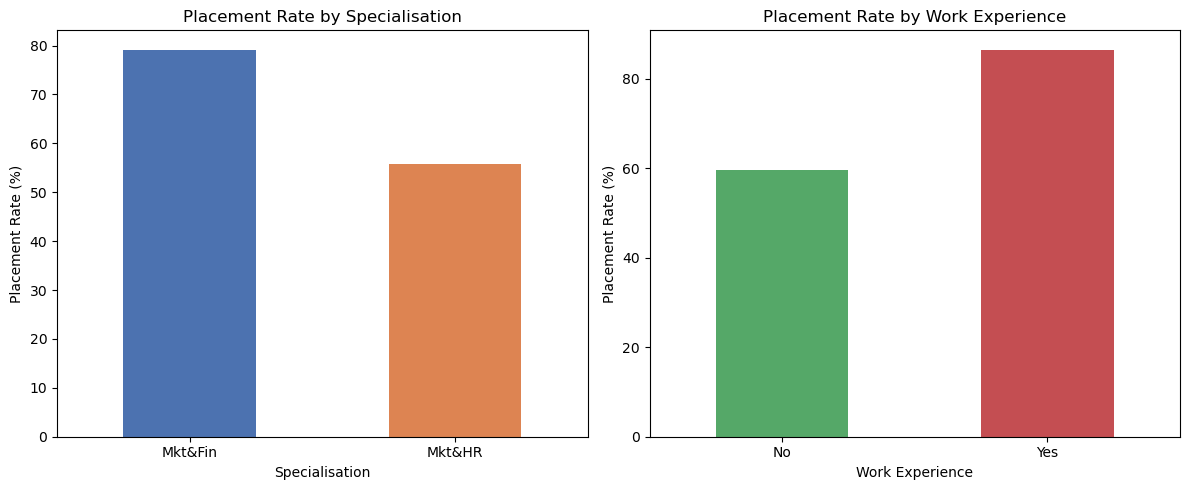

Placement rate by specialisation:
 specialisation
Mkt&Fin    79.2
Mkt&HR     55.8
Name: status, dtype: float64


In [146]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

spec_rate = data_clean.groupby('specialisation')['status'].apply(lambda s: (s == 'Placed').mean() * 100)
spec_rate.plot(kind='bar', ax=axes[0], color=['#4C72B0', '#DD8452'])
axes[0].set_title('Placement Rate by Specialisation')
axes[0].set_ylabel('Placement Rate (%)')
axes[0].set_xlabel('Specialisation')
axes[0].tick_params(axis='x', rotation=0)

workex_rate = data_clean.groupby('workex')['status'].apply(lambda s: (s == 'Placed').mean() * 100)
workex_rate.plot(kind='bar', ax=axes[1], color=['#55A868', '#C44E52'])
axes[1].set_title('Placement Rate by Work Experience')
axes[1].set_ylabel('Placement Rate (%)')
axes[1].set_xlabel('Work Experience')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

print("Placement rate by specialisation:\n", spec_rate.round(1))

In [147]:
print("\nPlacement rate by work experience:\n", workex_rate.round(1))


Placement rate by work experience:
 workex
No     59.6
Yes    86.5
Name: status, dtype: float64


Distribution of academic score by placement status

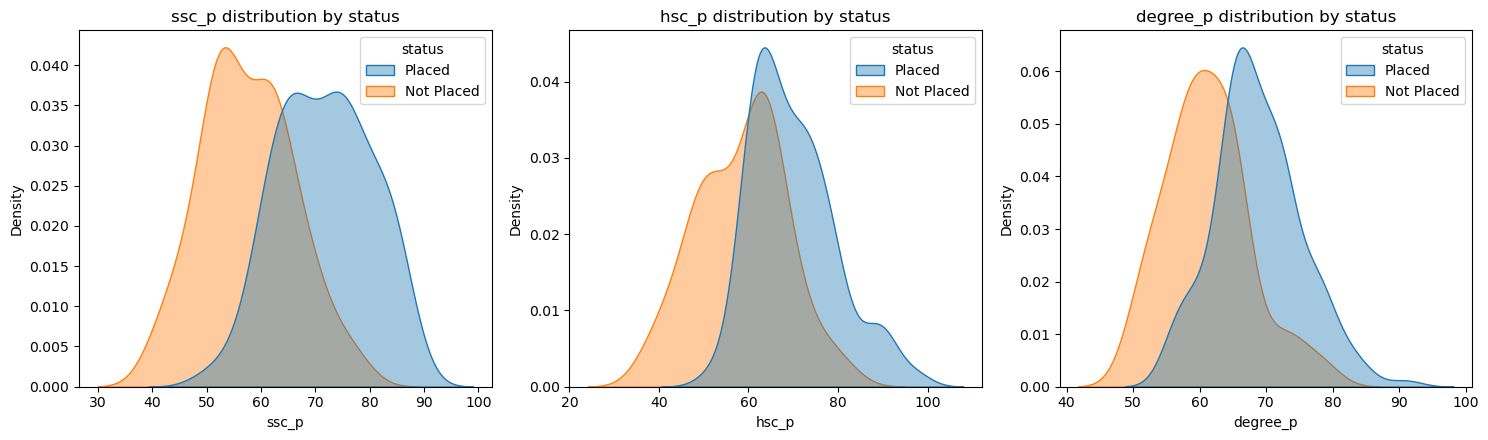

In [148]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, col in zip(axes, ['ssc_p', 'hsc_p', 'degree_p']):
    sns.kdeplot(data=data_clean, x=col, hue='status', fill=True, alpha=0.4, ax=ax, common_norm=False)
    ax.set_title(f'{col} distribution by status')
plt.tight_layout()
plt.show()

In [149]:
data_back=data_clean.copy()

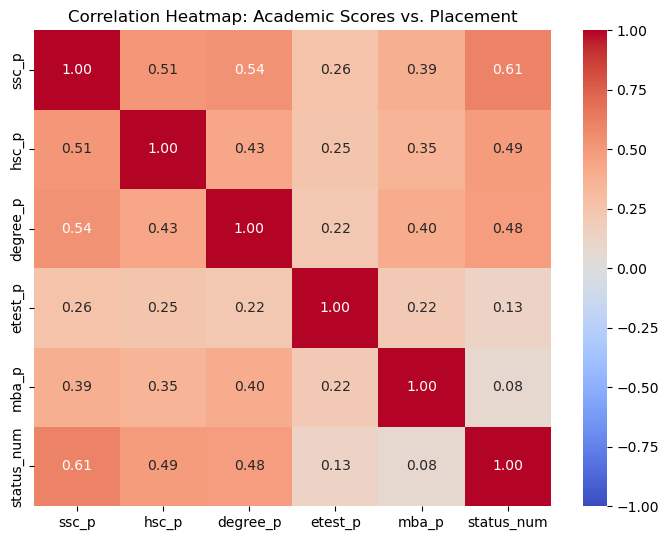

status_num    1.000000
ssc_p         0.607889
hsc_p         0.491228
degree_p      0.479861
etest_p       0.127639
mba_p         0.076922
Name: status_num, dtype: float64


In [150]:
data_clean['status_num'] = (data_clean['status'] == 'Placed').astype(int)
numeric_cols = ['ssc_p', 'hsc_p', 'degree_p', 'etest_p', 'mba_p', 'status_num']

plt.figure(figsize=(7, 5.5))
sns.heatmap(data_clean[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Heatmap: Academic Scores vs. Placement")
plt.tight_layout()
plt.show()

print(data_clean[numeric_cols].corr()['status_num'].sort_values(ascending=False))


## Does higher mba percentage corelate with placement?

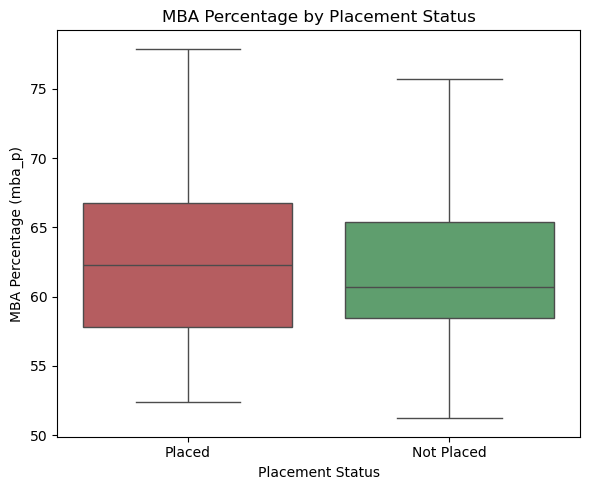

                 mean       std    min    max
status                                       
Not Placed  61.612836  5.705689  51.21  75.71
Placed      62.579392  5.884583  52.38  77.89


In [151]:
plt.figure(figsize=(6, 5))
sns.boxplot(data=data_clean, x='status', y='mba_p', hue='status', palette=['#C44E52', '#55A868'], legend=False)
plt.title('MBA Percentage by Placement Status')
plt.xlabel('Placement Status')
plt.ylabel('MBA Percentage (mba_p)')
plt.tight_layout()
plt.show()

print(data_clean.groupby('status')['mba_p'].describe()[['mean', 'std', 'min', 'max']])


## Feature Engineering

In [152]:
data_clean.head()

,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,status_num
0,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed,1
1,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed,1
2,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed,1
3,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,Not Placed,0
4,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed,1


In [153]:
data_clean=data_clean.drop(columns=['status'])

In [154]:
data_clean.head()

,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status_num
0,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,1
1,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,1
2,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,1
3,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,0
4,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,1


In [155]:
from sklearn.preprocessing import LabelEncoder

In [156]:
le=LabelEncoder()

In [157]:
data_clean['workex']=le.fit_transform(data_clean['workex'])

In [158]:
data_clean

,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status_num
0,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,0,55.0,Mkt&HR,58.80,1
1,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,1,86.5,Mkt&Fin,66.28,1
2,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,0,75.0,Mkt&Fin,57.80,1
3,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,0,66.0,Mkt&HR,59.43,0
4,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,0,96.8,Mkt&Fin,55.50,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
210,M,80.60,Others,82.00,Others,Commerce,77.60,Comm&Mgmt,0,91.0,Mkt&Fin,74.49,1
211,M,58.00,Others,60.00,Others,Science,72.00,Sci&Tech,0,74.0,Mkt&Fin,53.62,1
212,M,67.00,Others,67.00,Others,Commerce,73.00,Comm&Mgmt,1,59.0,Mkt&Fin,69.72,1
213,F,74.00,Others,66.00,Others,Commerce,58.00,Comm&Mgmt,0,70.0,Mkt&HR,60.23,1


In [159]:
data_clean['academic_average'] = data_clean[['ssc_p', 'hsc_p', 'degree_p']].mean(axis=1)

In [161]:
from sklearn.preprocessing import OneHotEncoder

In [162]:
ohe=OneHotEncoder()

In [166]:
data_clean.head()

,ssc_p,hsc_p,degree_p,workex,etest_p,mba_p,status_num,academic_average,gender_M,hsc_s_Commerce,hsc_s_Science,degree_t_Others,degree_t_Sci&Tech,specialisation_Mkt&HR,ssc_b_Others,hsc_b_Others
0,67.00,91.00,58.00,0,55.0,58.80,1,72.000000,True,True,False,False,True,True,True,True
1,79.33,78.33,77.48,1,86.5,66.28,1,78.380000,True,False,True,False,True,False,False,True
2,65.00,68.00,64.00,0,75.0,57.80,1,65.666667,True,False,False,False,False,False,False,False
3,56.00,52.00,52.00,0,66.0,59.43,0,53.333333,True,False,True,False,True,True,False,False
4,85.80,73.60,73.30,0,96.8,55.50,1,77.566667,True,True,False,False,False,False,False,False


In [169]:
data_clean

,ssc_p,hsc_p,degree_p,workex,etest_p,mba_p,status_num,academic_average,gender_M,hsc_s_Commerce,hsc_s_Science,degree_t_Others,degree_t_Sci&Tech,specialisation_Mkt&HR,ssc_b_Others,hsc_b_Others
0,67.00,91.00,58.00,0,55.0,58.80,1,72.000000,True,True,False,False,True,True,True,True
1,79.33,78.33,77.48,1,86.5,66.28,1,78.380000,True,False,True,False,True,False,False,True
2,65.00,68.00,64.00,0,75.0,57.80,1,65.666667,True,False,False,False,False,False,False,False
3,56.00,52.00,52.00,0,66.0,59.43,0,53.333333,True,False,True,False,True,True,False,False
4,85.80,73.60,73.30,0,96.8,55.50,1,77.566667,True,True,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
210,80.60,82.00,77.60,0,91.0,74.49,1,80.066667,True,True,False,False,False,False,True,True
211,58.00,60.00,72.00,0,74.0,53.62,1,63.333333,True,False,True,False,True,False,True,True
212,67.00,67.00,73.00,1,59.0,69.72,1,69.000000,True,True,False,False,False,False,True,True
213,74.00,66.00,58.00,0,70.0,60.23,1,66.000000,False,True,False,False,False,True,True,True


In [171]:
print("Shape after feature engineering:", data_clean.shape)
data_clean.head()

Shape after feature engineering: (215, 16)


,ssc_p,hsc_p,degree_p,workex,etest_p,mba_p,status_num,academic_average,gender_M,hsc_s_Commerce,hsc_s_Science,degree_t_Others,degree_t_Sci&Tech,specialisation_Mkt&HR,ssc_b_Others,hsc_b_Others
0,67.00,91.00,58.00,0,55.0,58.80,1,72.000000,True,True,False,False,True,True,True,True
1,79.33,78.33,77.48,1,86.5,66.28,1,78.380000,True,False,True,False,True,False,False,True
2,65.00,68.00,64.00,0,75.0,57.80,1,65.666667,True,False,False,False,False,False,False,False
3,56.00,52.00,52.00,0,66.0,59.43,0,53.333333,True,False,True,False,True,True,False,False
4,85.80,73.60,73.30,0,96.8,55.50,1,77.566667,True,True,False,False,False,False,False,False


In [173]:
from sklearn.model_selection import train_test_split

In [178]:
x = data_clean.drop(columns=['status_num'])
y = data_clean['status_num']

In [179]:
x

,ssc_p,hsc_p,degree_p,workex,etest_p,mba_p,academic_average,gender_M,hsc_s_Commerce,hsc_s_Science,degree_t_Others,degree_t_Sci&Tech,specialisation_Mkt&HR,ssc_b_Others,hsc_b_Others
0,67.00,91.00,58.00,0,55.0,58.80,72.000000,True,True,False,False,True,True,True,True
1,79.33,78.33,77.48,1,86.5,66.28,78.380000,True,False,True,False,True,False,False,True
2,65.00,68.00,64.00,0,75.0,57.80,65.666667,True,False,False,False,False,False,False,False
3,56.00,52.00,52.00,0,66.0,59.43,53.333333,True,False,True,False,True,True,False,False
4,85.80,73.60,73.30,0,96.8,55.50,77.566667,True,True,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
210,80.60,82.00,77.60,0,91.0,74.49,80.066667,True,True,False,False,False,False,True,True
211,58.00,60.00,72.00,0,74.0,53.62,63.333333,True,False,True,False,True,False,True,True
212,67.00,67.00,73.00,1,59.0,69.72,69.000000,True,True,False,False,False,False,True,True
213,74.00,66.00,58.00,0,70.0,60.23,66.000000,False,True,False,False,False,True,True,True


In [180]:
y

0      1
1      1
2      1
3      0
4      1
      ..
210    1
211    1
212    1
213    1
214    0
Name: status_num, Length: 215, dtype: int64

In [181]:
bool_cols = x.select_dtypes(include='bool').columns
x[bool_cols] = x[bool_cols].astype(int)

In [182]:
x

,ssc_p,hsc_p,degree_p,workex,etest_p,mba_p,academic_average,gender_M,hsc_s_Commerce,hsc_s_Science,degree_t_Others,degree_t_Sci&Tech,specialisation_Mkt&HR,ssc_b_Others,hsc_b_Others
0,67.00,91.00,58.00,0,55.0,58.80,72.000000,1,1,0,0,1,1,1,1
1,79.33,78.33,77.48,1,86.5,66.28,78.380000,1,0,1,0,1,0,0,1
2,65.00,68.00,64.00,0,75.0,57.80,65.666667,1,0,0,0,0,0,0,0
3,56.00,52.00,52.00,0,66.0,59.43,53.333333,1,0,1,0,1,1,0,0
4,85.80,73.60,73.30,0,96.8,55.50,77.566667,1,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
210,80.60,82.00,77.60,0,91.0,74.49,80.066667,1,1,0,0,0,0,1,1
211,58.00,60.00,72.00,0,74.0,53.62,63.333333,1,0,1,0,1,0,1,1
212,67.00,67.00,73.00,1,59.0,69.72,69.000000,1,1,0,0,0,0,1,1
213,74.00,66.00,58.00,0,70.0,60.23,66.000000,0,1,0,0,0,1,1,1


In [184]:
print("Feature matrix shape:", x.shape)
print("Target distribution:\n", y.value_counts())

Feature matrix shape: (215, 15)
Target distribution:
 status_num
1    148
0     67
Name: count, dtype: int64


In [186]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=42)

In [188]:
from sklearn.preprocessing import StandardScaler

In [189]:
ss=StandardScaler()

In [191]:
x_train_scaled = ss.fit_transform(x_train)
x_test_scaled = ss.transform(x_test)

In [192]:
print("Train shape:", x_train.shape, " Test shape:", x_test.shape)
print("Train target balance:\n", y_train.value_counts(normalize=True).round(2))
print("Test target balance:\n", y_test.value_counts(normalize=True).round(2))

Train shape: (172, 15)  Test shape: (43, 15)
Train target balance:
 status_num
1    0.68
0    0.32
Name: proportion, dtype: float64
Test target balance:
 status_num
1    0.72
0    0.28
Name: proportion, dtype: float64


In [194]:
from sklearn.linear_model import LogisticRegression

In [195]:
lr=LogisticRegression()

In [197]:
lr.fit(x_train_scaled, y_train)
y_pred = lr.predict(x_test_scaled)
print("Model trained successfully.")

Model trained successfully.


## Evaluation

In [198]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, classification_report, confusion_matrix,
                              ConfusionMatrixDisplay)

In [199]:
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

In [200]:
print(f"Accuracy : {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall   : {rec:.3f}")
print(f"F1 score : {f1:.3f}")
print()
print(classification_report(y_test, y_pred, target_names=['Not Placed', 'Placed']))

Accuracy : 0.884
Precision: 0.906
Recall   : 0.935
F1 score : 0.921

              precision    recall  f1-score   support

  Not Placed       0.82      0.75      0.78        12
      Placed       0.91      0.94      0.92        31

    accuracy                           0.88        43
   macro avg       0.86      0.84      0.85        43
weighted avg       0.88      0.88      0.88        43



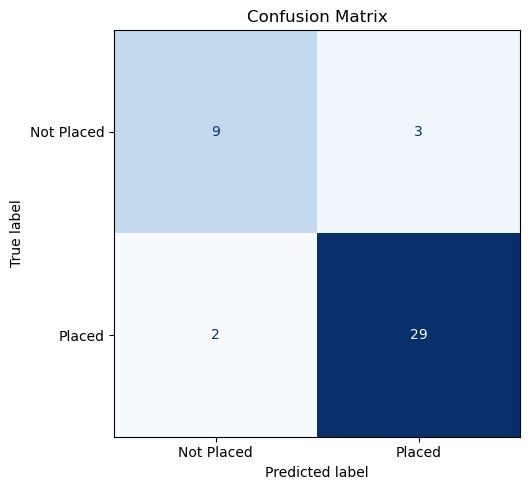

In [201]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Placed', 'Placed'])
fig, ax = plt.subplots(figsize=(5.5, 5))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

## Strongest Predictor

In [202]:
coef_df = pd.DataFrame({
    'feature': x.columns,
    'coefficient': lr.coef_[0]
}).sort_values('coefficient', ascending=False)

print(coef_df.to_string(index=False))


              feature  coefficient
                ssc_p     1.555809
     academic_average     1.279468
             degree_p     0.939597
                hsc_p     0.645673
               workex     0.608176
             gender_M     0.567875
         ssc_b_Others     0.223223
      degree_t_Others    -0.128580
              etest_p    -0.149162
specialisation_Mkt&HR    -0.154262
         hsc_b_Others    -0.162503
        hsc_s_Science    -0.224937
    degree_t_Sci&Tech    -0.495317
       hsc_s_Commerce    -0.525620
                mba_p    -0.985725


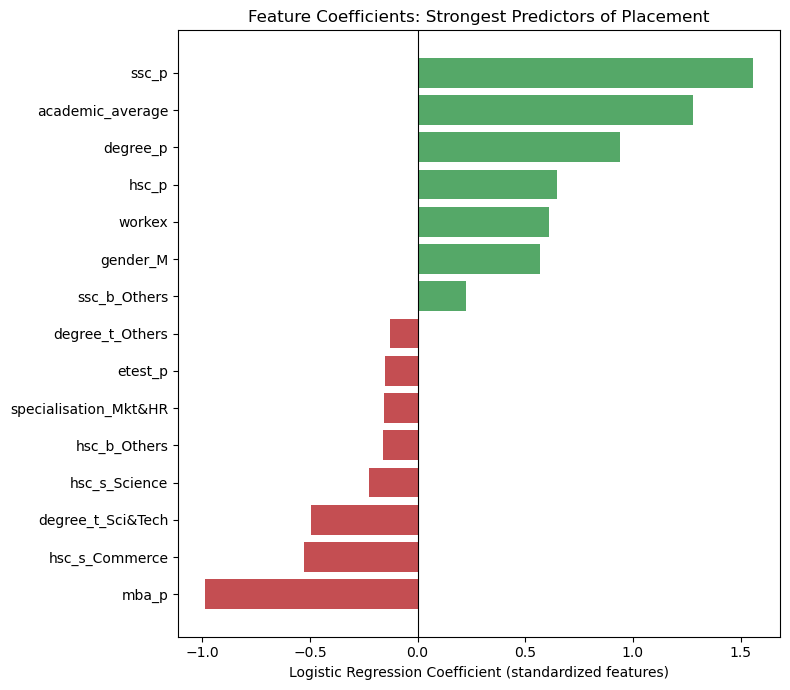

In [203]:
plt.figure(figsize=(8, 7))
colors = ['#55A868' if c > 0 else '#C44E52' for c in coef_df['coefficient']]
plt.barh(coef_df['feature'], coef_df['coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Logistic Regression Coefficient (standardized features)')
plt.title('Feature Coefficients: Strongest Predictors of Placement')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()